# Movie Recommendation System

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import plotly.express as px
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')
from fuzzywuzzy import process
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Load Dataset

In [2]:
import zipfile
import urllib.request
import os

# Download the dataset directly
url = 'http://files.grouplens.org/datasets/movielens/ml-100k.zip'
zip_path = 'ml-100k.zip'

print("Downloading MovieLens 100K dataset...")
urllib.request.urlretrieve(url, zip_path)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('.')

print("Dataset downloaded and extracted successfully!")
print("="*50)
# Load the data
ratings = pd.read_csv('ml-100k/u.data', sep='\t', 
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     names=['movie_id', 'title', 'release_date', 'video_release_date',
                            'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                            'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 
                            'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 
                            'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
                     header=None)

print("\nRatings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("="*50)
print(f"\nUnique users: {ratings['user_id'].nunique()}")
print(f"Unique movies: {ratings['movie_id'].nunique()}")
print(f"Total ratings: {len(ratings):,}")
print("="*50)
print("\nFirst few rows in ratings:")
print(ratings.head())

Dataset downloaded and extracted successfully!

Ratings shape: (100000, 4)
Movies shape: (1682, 24)

Unique users: 943
Unique movies: 1682
Total ratings: 100,000

First few rows in ratings:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


In [3]:
print("First few rows in Movies:")
print(movies.head())

First few rows in Movies:
   movie_id              title release_date  video_release_date  \
0         1   Toy Story (1995)  01-Jan-1995                 NaN   
1         2   GoldenEye (1995)  01-Jan-1995                 NaN   
2         3  Four Rooms (1995)  01-Jan-1995                 NaN   
3         4  Get Shorty (1995)  01-Jan-1995                 NaN   
4         5     Copycat (1995)  01-Jan-1995                 NaN   

                                            imdb_url  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0       0   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...        0       1   
4  http://us.imdb.com/M/title-exact?Copycat%20(1995)        0       0   

   Adventure  Animation  Children  Comedy  Crime  Documentary  Drama  Fantasy  \
0          0          1         1       1      0   

##  Exploratory Data Analysis (EDA)

In [4]:
print("Ratings Statistics:")
print(ratings.describe())

Ratings Statistics:
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08


In [5]:
print("Movies Statistics:")
print(movies.describe())

Movies Statistics:
          movie_id  video_release_date      unknown       Action    Adventure  \
count  1682.000000                 0.0  1682.000000  1682.000000  1682.000000   
mean    841.500000                 NaN     0.001189     0.149227     0.080262   
std     485.695893                 NaN     0.034473     0.356418     0.271779   
min       1.000000                 NaN     0.000000     0.000000     0.000000   
25%     421.250000                 NaN     0.000000     0.000000     0.000000   
50%     841.500000                 NaN     0.000000     0.000000     0.000000   
75%    1261.750000                 NaN     0.000000     0.000000     0.000000   
max    1682.000000                 NaN     1.000000     1.000000     1.000000   

         Animation     Children       Comedy        Crime  Documentary  \
count  1682.000000  1682.000000  1682.000000  1682.000000  1682.000000   
mean      0.024970     0.072533     0.300238     0.064804     0.029727   
std       0.156081     0.2594

In [6]:
movies.isna().sum()

movie_id                 0
title                    0
release_date             1
video_release_date    1682
imdb_url                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Children                 0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64

In [7]:
ratings.isna().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

### SO the column video_release_date in movies is missing >>> we will drop it
### Also the column imdb_url and unknown we will drop them , we don't need them

In [8]:
movies.drop(columns=["video_release_date","imdb_url","unknown"],inplace=True)

## Analysis for Rating per User and Movie

In [9]:
ratings_per_user = ratings.groupby('user_id').size()
ratings_per_movie = ratings.groupby('movie_id').size()
print(f"Average ratings per user: {ratings_per_user.mean():.2f}")
print(f"Median ratings per user: {ratings_per_user.median():.2f}")
print(f"Max ratings by a user: {ratings_per_user.max()}")
print("="*45)
print(f"Average ratings per movie: {ratings_per_movie.mean():.1f}")
print(f"Median ratings per movie: {ratings_per_movie.median():.1f}")
print(f"Max ratings for a movie: {ratings_per_movie.max()}")

Average ratings per user: 106.04
Median ratings per user: 65.00
Max ratings by a user: 737
Average ratings per movie: 59.5
Median ratings per movie: 27.0
Max ratings for a movie: 583


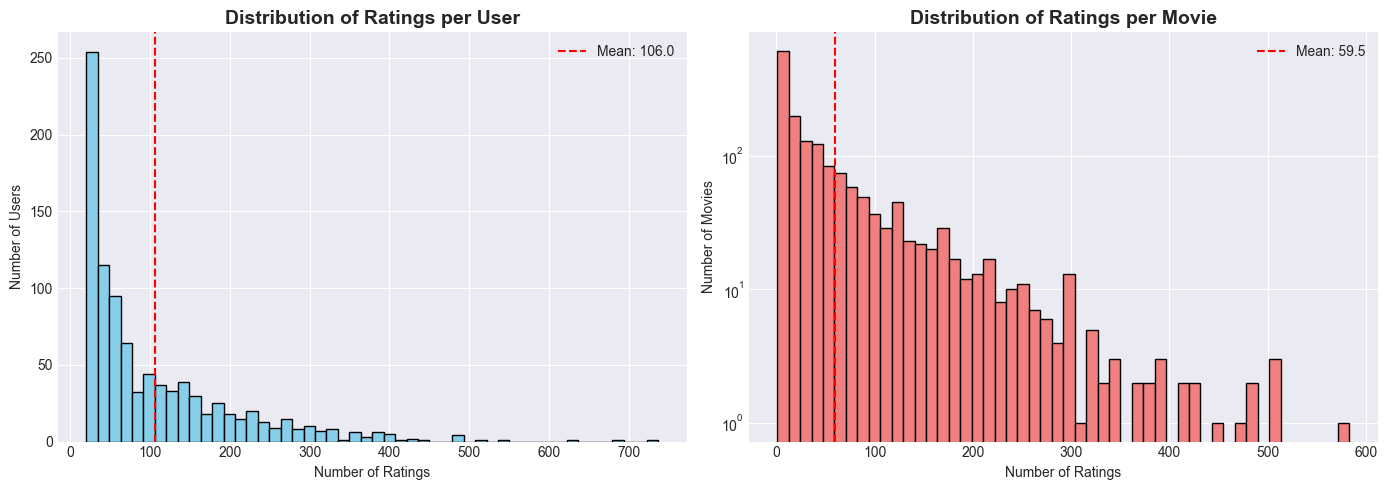

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ratings_per_user, bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Distribution of Ratings per User', fontsize=14, fontweight='bold')
axes[0].axvline(ratings_per_user.mean(), color='red', linestyle='--', label=f'Mean: {ratings_per_user.mean():.1f}')
axes[0].legend()

axes[1].hist(ratings_per_movie, bins=50, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Movies')
axes[1].set_title('Distribution of Ratings per Movie', fontsize=14, fontweight='bold')
axes[1].axvline(ratings_per_movie.mean(), color='red', linestyle='--', label=f'Mean: {ratings_per_movie.mean():.1f}')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Sparsity vs Density

In [11]:
num_users = ratings['user_id'].nunique()
num_movies = ratings['movie_id'].nunique()

sparsity = 1 - (len(ratings) / (num_users * num_movies))
print(f"Sparsity in rating : {round(sparsity*100,2)} %")
print(f"Density in the rating :{round((1-sparsity)*100,2)} %")

Sparsity in rating : 93.7 %
Density in the rating :6.3 %


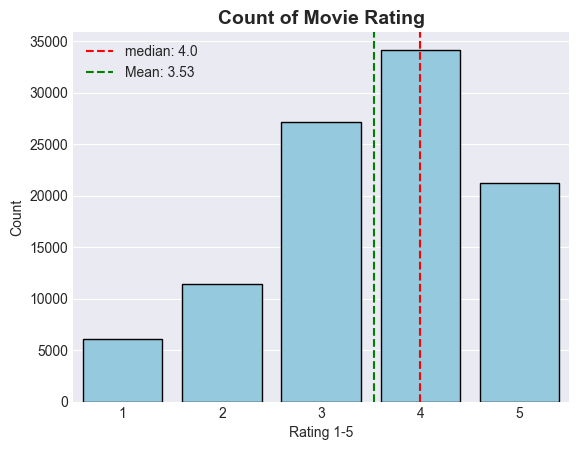

So that the Mean of the Rating is : 3.53
Mean Rating per User is :3.59 


In [12]:
median_value = ratings["rating"].median()
mean_value = ratings["rating"].mean()
sns.countplot(x="rating", data=ratings  ,color='skyblue', edgecolor='black' )
plt.title("Count of Movie Rating" , fontsize=14, fontweight='bold' )
plt.xlabel("Rating 1-5")
plt.ylabel("Count")
plt.axvline(x=median_value - 1, color='red', linestyle='--',label=f'median: {ratings["rating"].median():.1f}')
plt.axvline(mean_value - 1, color='green', linestyle='--',label=f'Mean: {mean_value:.2f}')
plt.legend()
plt.show()
print("So that the Mean of the Rating is :",(round(ratings["rating"].mean() , 2)))
MEAN_RATING =  ratings.groupby("user_id")["rating"].mean()
print(f"Mean Rating per User is :{round(MEAN_RATING.mean(),2)} ")

## Most Popular Movies

In [13]:
movie_stats = ratings.groupby('movie_id').agg({
    'rating': ['count', 'mean']
}).reset_index()
movie_stats.columns = ['movie_id', 'num_ratings', 'avg_rating']
movie_stats = movie_stats.merge(movies[['movie_id', 'title']], on='movie_id')

top_rated_movies = movie_stats.nlargest(10, 'num_ratings')
print("\nTop 10 Most Rated Movies:")
print("="*60)
print(top_rated_movies[['title', 'num_ratings', 'avg_rating']].to_string(index=False))
print("-"*100)
popular_movies = movie_stats[movie_stats['num_ratings'] >= 100]
top_avg_movies = popular_movies.nlargest(10, 'avg_rating')
print("\nTop 10 Highest Rated Movies (min 100 ratings):") 
print("="*60)
print(top_avg_movies[['title', 'num_ratings', 'avg_rating']].to_string(index=False))


Top 10 Most Rated Movies:
                        title  num_ratings  avg_rating
             Star Wars (1977)          583    4.358491
               Contact (1997)          509    3.803536
                 Fargo (1996)          508    4.155512
    Return of the Jedi (1983)          507    4.007890
             Liar Liar (1997)          485    3.156701
  English Patient, The (1996)          481    3.656965
                Scream (1996)          478    3.441423
             Toy Story (1995)          452    3.878319
         Air Force One (1997)          431    3.631090
Independence Day (ID4) (1996)          429    3.438228
----------------------------------------------------------------------------------------------------

Top 10 Highest Rated Movies (min 100 ratings):
                           title  num_ratings  avg_rating
           Close Shave, A (1995)          112    4.491071
         Schindler's List (1993)          298    4.466443
      Wrong Trousers, The (1993)          118

## To Get The Least Rated Movie In The Dataset

In [14]:
MEAN_RATING = ratings.groupby("movie_id")["rating"].mean()
lowest_rated_movie = MEAN_RATING.idxmin()
print("Lowest_Movie_Rated :")
print("-"*50)
print(movies[movies["movie_id"] == lowest_rated_movie])

Lowest_Movie_Rated :
--------------------------------------------------
     movie_id                                        title release_date  \
313       314  3 Ninjas: High Noon At Mega Mountain (1998)  01-Jan-1997   

     Action  Adventure  Animation  Children  Comedy  Crime  Documentary  \
313       1          0          0         1       0      0            0   

     Drama  Fantasy  Film-Noir  Horror  Musical  Mystery  Romance  Sci-Fi  \
313      0        0          0       0        0        0        0       0   

     Thriller  War  Western  
313         0    0        0  


## To Get The Highest Rated Movie In The Dataset

In [15]:
highest_rated_movie = MEAN_RATING.idxmax()
print("Highest_Movie_Rated :")
print("-"*50)
print(movies[movies["movie_id"] == highest_rated_movie])

Highest_Movie_Rated :
--------------------------------------------------
     movie_id                          title release_date  Action  Adventure  \
813       814  Great Day in Harlem, A (1994)  01-Jan-1994       0          0   

     Animation  Children  Comedy  Crime  Documentary  Drama  Fantasy  \
813          0         0       0      0            1      0        0   

     Film-Noir  Horror  Musical  Mystery  Romance  Sci-Fi  Thriller  War  \
813          0       0        0        0        0       0         0    0   

     Western  
813        0  


### Honestly I Didn't Hear About Great Day in Harlem Before 
## So we will check for the users who rated that movie

In [16]:
print("To see how many rating does the HIGHEST rated movie have")
print("-"*70)
print(ratings[ratings["movie_id"]== highest_rated_movie])

To see how many rating does the HIGHEST rated movie have
----------------------------------------------------------------------
      user_id  movie_id  rating  timestamp
6519       13       814       5  886302261


### so it is rated by only one user 
### so we're gonna apply a better method called :
##                                     Bayesian Average Method
## $r_{i} = \frac{C \times m + \Sigma{\text{reviews}}}{C+N}$
### where $C$ represents our confidence, $m$ represents our prior, and $N$ is the total number of reviews for movie $i$. In this case, our prior $m$ will be the average rating across all movies. By defintion, C represents "the typical data set size". Let's make $C$ be the average number of ratings for a given movie?

In [17]:
movie_rated=ratings.groupby("movie_id")["rating"].agg(["count","mean"])
C=movie_rated["count"].mean()
m=movie_rated["mean"].mean()
print(f"The Average Number of Rating for Movie is : {C:.2f}")
print("="*50)
print(f"The Average Rating for Movie is : {m:.2f}")

The Average Number of Rating for Movie is : 59.45
The Average Rating for Movie is : 3.08


## The Function of Bayesian AVG Method

In [18]:
def baye_avg(ratings):
    bayesian_rating=(C*m+ratings.sum())/(C+ratings.count())
    return round(bayesian_rating,3)
  

### To check for Great Day in Harlem movie By using Bayesian Method

In [19]:
Great_Day_in_Harlem = pd.Series([5])
baye_avg(Great_Day_in_Harlem)

np.float64(3.108)

### Let's See The Highest Rated Movie In Our Data By Bayesian Function 

In [20]:
bayesian_ave_ratnig = ratings.groupby("movie_id")["rating"].agg(baye_avg).reset_index()
bayesian_ave_ratnig.columns=["movie_id","bayesian_ave_rating"]
#bayesian_ave_ratnig.head()
movie_update = movie_rated.merge(bayesian_ave_ratnig,on="movie_id")
movie_update=movie_update.merge(movies[["movie_id","title"]])
print("\n The Data That Include The Mean and Bayesian AVG :")
print("="*55)
print(movie_update.head())
print("--"*55)
print("\n the top 10 movies based on the Bayesian AVG :")
print("="*55)
movie_update.sort_values(by="bayesian_ave_rating",ascending=False).head(10).reset_index(drop=True)



 The Data That Include The Mean and Bayesian AVG :
   movie_id  count      mean  bayesian_ave_rating              title
0         1    452  3.878319                3.785   Toy Story (1995)
1         2    131  3.206107                3.166   GoldenEye (1995)
2         3     90  3.033333                3.050  Four Rooms (1995)
3         4    209  3.550239                3.445  Get Shorty (1995)
4         5     86  3.302326                3.210     Copycat (1995)
--------------------------------------------------------------------------------------------------------------

 the top 10 movies based on the Bayesian AVG :


,movie_id,count,mean,bayesian_ave_rating,title
0,50,583,4.358491,4.240,Star Wars (1977)
1,318,298,4.466443,4.235,Schindler's List (1993)
2,64,283,4.445230,4.208,"Shawshank Redemption, The (1994)"
3,483,243,4.456790,4.185,Casablanca (1942)
4,12,267,4.385768,4.147,"Usual Suspects, The (1995)"
5,127,413,4.283293,4.131,"Godfather, The (1972)"
6,98,390,4.289744,4.129,"Silence of the Lambs, The (1991)"
7,174,420,4.252381,4.107,Raiders of the Lost Ark (1981)
8,603,209,4.387560,4.097,Rear Window (1954)
9,313,350,4.245714,4.076,Titanic (1997)


In [21]:
print("\n the bottom 10 movies based on the Bayesian AVG :")
print("="*55)
movie_update.sort_values(by="bayesian_ave_rating",ascending=True).head(10).reset_index(drop=True)


 the bottom 10 movies based on the Bayesian AVG :


,movie_id,count,mean,bayesian_ave_rating,title
0,688,44,1.840909,2.551,Leave It to Beaver (1997)
1,687,69,2.188406,2.599,McHale's Navy (1997)
2,122,106,2.339623,2.604,"Cable Guy, The (1996)"
3,890,43,1.953488,2.605,Mortal Kombat: Annihilation (1997)
4,988,86,2.313953,2.625,"Beautician and the Beast, The (1997)"
5,931,57,2.157895,2.627,"Island of Dr. Moreau, The (1996)"
6,743,39,1.948718,2.629,"Crow: City of Angels, The (1996)"
7,120,67,2.238806,2.632,Striptease (1996)
8,243,132,2.439394,2.637,Jungle2Jungle (1997)
9,424,19,1.315789,2.650,Children of the Corn: The Gathering (1996)


### So For The Conclusion ;  We Can See That The Lowest Rated Movie Really Is : Leave It to Beaver (1997)
### and The Highest Rated Movie Is : Star Wars (1977)
## That's After Applying The Bayesian Method


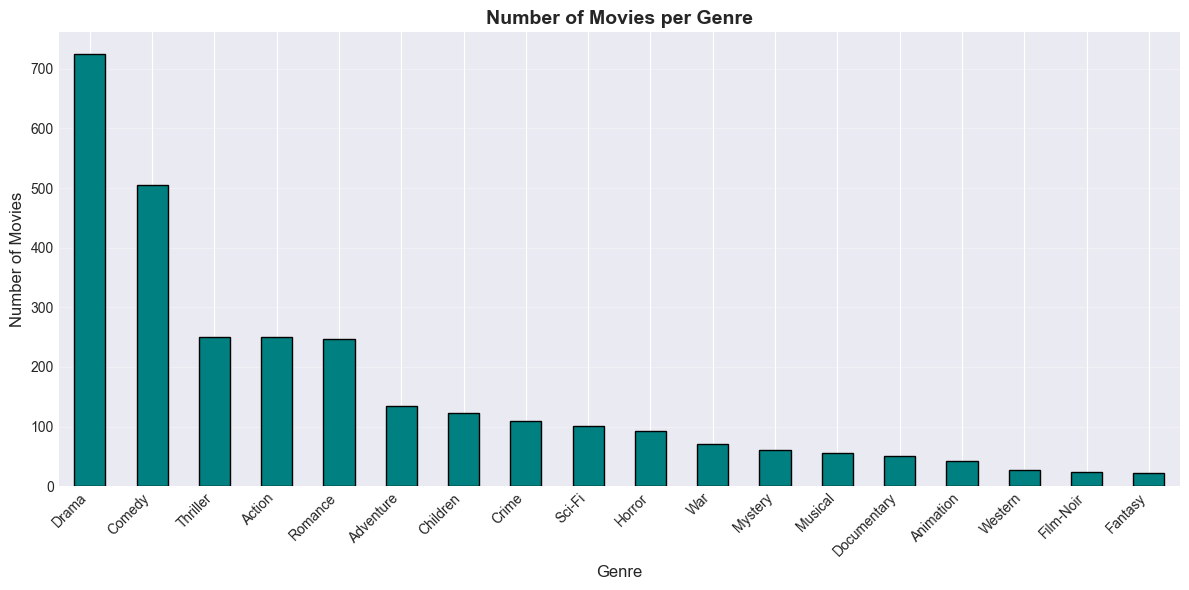


Genre Distribution:
Drama       :  725 movies ( 43.1%)
Comedy      :  505 movies ( 30.0%)
Thriller    :  251 movies ( 14.9%)
Action      :  251 movies ( 14.9%)
Romance     :  247 movies ( 14.7%)
Adventure   :  135 movies (  8.0%)
Children    :  122 movies (  7.3%)
Crime       :  109 movies (  6.5%)
Sci-Fi      :  101 movies (  6.0%)
Horror      :   92 movies (  5.5%)
War         :   71 movies (  4.2%)
Mystery     :   61 movies (  3.6%)
Musical     :   56 movies (  3.3%)
Documentary :   50 movies (  3.0%)
Animation   :   42 movies (  2.5%)
Western     :   27 movies (  1.6%)
Film-Noir   :   24 movies (  1.4%)
Fantasy     :   22 movies (  1.3%)


In [22]:
genre_columns = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
                 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
                 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# Count movies per genre
genre_counts = movies[genre_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Number of Movies per Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nGenre Distribution:")
for genre, count in genre_counts.items():
    pct = count / len(movies) * 100
    print(f"{genre:12s}: {count:4d} movies ({pct:5.1f}%)")

In [23]:
def create_X(df):
    """
    Generates a sparse matrix from ratings dataframe.
    
    Args:
        df: pandas dataframe containing 3 columns (user_id, movie_id, rating)
    
    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['user_id'].nunique()
    N = df['movie_id'].nunique()

    user_mapper = dict(zip(np.unique(df["user_id"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movie_id"]), list(range(N))))
    
    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["user_id"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movie_id"])))
    
    user_index = [user_mapper[i] for i in df['user_id']]
    item_index = [movie_mapper[i] for i in df['movie_id']]

    X = csr_matrix((df["rating"], (user_index,item_index)), shape=(M,N))
    
    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(ratings)
X.shape

(943, 1682)

## Cosine Similarity

In [24]:
genre_features = movies[genre_columns].values

print(f"\nGenre feature matrix shape: {genre_features.shape}")
print(f"Features per movie: {genre_features.shape[1]}")
cosine_sim = cosine_similarity(genre_features, genre_features)

print(f"\nCosine similarity matrix shape: {cosine_sim.shape}")
print(f"Similarity range: [{cosine_sim.min():.3f}, {cosine_sim.max():.3f}]")


Genre feature matrix shape: (1682, 18)
Features per movie: 18

Cosine similarity matrix shape: (1682, 1682)
Similarity range: [0.000, 1.000]


## Helper Functions

In [25]:
def movie_finder(title, threshold=80):
    """
    Find closest matching movie title using fuzzy matching.
    
    Args:
        title: Search query string
        threshold: Minimum similarity score (0-100)
    
    Returns:
        Matched movie title
    """
    all_titles = movies["title"].tolist()
    closest_match = process.extractOne(title, all_titles)
    if closest_match is None:
        raise ValueError(f"No movies found matching '{title}'")
    
    matched_title, score = closest_match[0], closest_match[1]
    if score < threshold:
        print(f"Warning: Low match score ({score}%). Best match: '{matched_title}'")
    
    return matched_title


def get_movie_info(title):
    """
    Get detailed information about a movie.
    
    Args:
        title: Movie title
    
    Returns:
        Dictionary with movie information
    """
    matched_title = movie_finder(title)
    movie_data = movies[movies['title'] == matched_title].iloc[0]
    genres = [genre for genre in genre_columns if movie_data[genre] == 1]
    movie_id = movie_data['movie_id']
    movie_ratings = ratings[ratings['movie_id'] == movie_id]
    
    info = {
        'title': matched_title,
        'movie_id': movie_id,
        'genres': ', '.join(genres) if genres else 'Unknown',
        'num_ratings': len(movie_ratings),
        'avg_rating': movie_ratings['rating'].mean() if len(movie_ratings) > 0 else 0
    }
    
    return info


def display_movie_info(info):
    
    print("\n" + "="*60)
    print(f"{info['title']}")
    print("="*60)
    print(f"Movie ID: {info['movie_id']}")
    print(f"Genres: {info['genres']}")
    print(f"Number of Ratings: {info['num_ratings']}")
    print(f"Average Rating: {info['avg_rating']:.2f} / 5.0")
    print("="*60)

## Core of Recommendation System

In [26]:
def get_content_based_recommendations(title, n_recommendations=10, min_similarity=0.0):
    """
    Get movie recommendations based on content similarity (genres).
    
    Args:
        title: Movie title to search for
        n_recommendations: Number of recommendations to return
        min_similarity: Minimum similarity score threshold (0-1)
    
    Returns:
        DataFrame with recommended movies and similarity scores
    """
    try:
        matched_title = movie_finder(title)
        movie_info = get_movie_info(matched_title)
        display(movie_info)
        
        movie_with_index = dict(zip(movies['title'], list(movies.index)))
        movie_idx = movie_with_index[matched_title]
        
        simi_scores = list(enumerate(cosine_sim[movie_idx]))
        simi_scores = sorted(simi_scores, key=lambda x: x[1], reverse=True)
        
        simi_scores = [(idx, score) for idx, score in simi_scores[1:] if score >= min_similarity]
        simi_scores = simi_scores[:n_recommendations]
        
        if not simi_scores:
            print(f"\n No recommendations found with similarity >= {min_similarity}")
            return pd.DataFrame()
        
        # Get movie details
        similar_indices = [i[0] for i in simi_scores]
        similarity_values = [i[1] for i in simi_scores]
        
        # Create recommendations dataframe
        recommendations_df = movies.iloc[similar_indices][['movie_id', 'title'] + genre_columns].copy()
        recommendations_df['similarity_score'] = similarity_values
        
        # Add genre string
        recommendations_df['genres'] = recommendations_df.apply(
            lambda row: ', '.join([g for g in genre_columns if row[g] == 1]), axis=1
        )
        
        # Add rating statistics
        rating_stats = ratings.groupby('movie_id').agg({
            'rating': ['count', 'mean']
        }).reset_index()
        rating_stats.columns = ['movie_id', 'num_ratings', 'avg_rating']
        
        recommendations_df = recommendations_df.merge(rating_stats, on='movie_id', how='left')
        recommendations_df['num_ratings'] = recommendations_df['num_ratings'].fillna(0).astype(int)
        recommendations_df['avg_rating'] = recommendations_df['avg_rating'].fillna(0)
        
        # Select final columns
        final_cols = ['title', 'genres', 'similarity_score', 'num_ratings', 'avg_rating']
        recommendations_df = recommendations_df[final_cols]
        
        # Display recommendations
        print(f"\n Because you watched '{matched_title}', you might like:\n")
        
        return recommendations_df
    
    except Exception as e:
        print(f"Error: {str(e)}")
        return pd.DataFrame()

In [27]:
def get_collaborative_recommendations(title, n_recommendations=10):
    """
    Get movie recommendations based on collaborative filtering (user ratings).
    
    Args:
        title: Movie title to search for
        n_recommendations: Number of recommendations to return
    
    Returns:
        DataFrame with recommended movies
    """
    try:
        matched_title = movie_finder(title)
        movie_info = get_movie_info(matched_title)
        display_movie_info(movie_info)

        movie_id = movies[movies['title'] == matched_title]['movie_id'].values[0]

        if movie_id not in movie_mapper:
            print(f"\n Movie '{matched_title}' has no ratings. Cannot provide collaborative recommendations.")
            return pd.DataFrame()
  
        X_t = X.T
        movie_idx = movie_mapper[movie_id]
        movie_vec = X_t[movie_idx].reshape(1, -1)
        
        knn = NearestNeighbors(n_neighbors=n_recommendations+1, algorithm="brute", metric="cosine")
        knn.fit(X_t)

        distances, neighbor_indices = knn.kneighbors(movie_vec, return_distance=True)

        similar_movie_ids = [movie_inv_mapper[idx] for idx in neighbor_indices.flatten()[1:]]
        similarity_scores = 1 - distances.flatten()[1:]

        recommendations_df = movies[movies['movie_id'].isin(similar_movie_ids)].copy()

        score_dict = dict(zip(similar_movie_ids, similarity_scores))
        recommendations_df['similarity_score'] = recommendations_df['movie_id'].map(score_dict)

        recommendations_df['genres'] = recommendations_df.apply(
            lambda row: ', '.join([g for g in genre_columns if row[g] == 1]), axis=1
        )
        

        rating_stats = ratings.groupby('movie_id').agg({
            'rating': ['count', 'mean']
        }).reset_index()
        rating_stats.columns = ['movie_id', 'num_ratings', 'avg_rating']
        
        recommendations_df = recommendations_df.merge(rating_stats, on='movie_id', how='left')
      
        final_cols = ['title', 'genres', 'similarity_score', 'num_ratings', 'avg_rating']
        recommendations_df = recommendations_df[final_cols].sort_values('similarity_score', ascending=False)
        
        print(f"\nUsers who liked '{matched_title}' also liked:\n")
        
        return recommendations_df
    
    except Exception as e:
        print(f"Error: {str(e)}")
        return pd.DataFrame()

In [28]:
recommendations_content = get_content_based_recommendations("Mission: Impossible", n_recommendations=10)
print(recommendations_content.to_string(index=False))

{'title': 'Mission: Impossible (1996)',
 'movie_id': np.int64(405),
 'genres': 'Action, Adventure, Mystery',
 'num_ratings': 344,
 'avg_rating': np.float64(3.313953488372093)}


 Because you watched 'Mission: Impossible (1996)', you might like:

                                    title                             genres  similarity_score  num_ratings  avg_rating
                             Congo (1995) Action, Adventure, Mystery, Sci-Fi          0.866025           42    2.452381
       Ghost and the Darkness, The (1996)                  Action, Adventure          0.816497          128    3.203125
           Raiders of the Lost Ark (1981)                  Action, Adventure          0.816497          420    4.252381
Indiana Jones and the Last Crusade (1989)                  Action, Adventure          0.816497          331    3.930514
                Kull the Conqueror (1997)                  Action, Adventure          0.816497           35    2.714286
                        Highlander (1986)                  Action, Adventure          0.816497          153    3.535948
     Adventures of Robin Hood, The (1938)                  Action, Adventure          0.816

In [29]:
recommendations_collab = get_collaborative_recommendations("Mission: Impossible", n_recommendations=10)
print(recommendations_collab.to_string(index=False))


Mission: Impossible (1996)
Movie ID: 405
Genres: Action, Adventure, Mystery
Number of Ratings: 344
Average Rating: 3.31 / 5.0

Users who liked 'Mission: Impossible (1996)' also liked:

                          title                                  genres  similarity_score  num_ratings  avg_rating
  Independence Day (ID4) (1996)                     Action, Sci-Fi, War          0.781254          429    3.438228
               Rock, The (1996)             Action, Adventure, Thriller          0.720355          378    3.693122
                 Twister (1996)             Action, Adventure, Thriller          0.681107          293    3.215017
                  Eraser (1996)                        Action, Thriller          0.679930          206    3.150485
            Broken Arrow (1996)                        Action, Thriller          0.670803          254    3.031496
               Toy Story (1995)             Animation, Children, Comedy          0.641322          452    3.878319
Star Trek